<a target="_blank" href="https://colab.research.google.com/github/TransformerLensOrg/TransformerLens/blob/main/demos/LLaVA.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### LLaVA Demo with TransformerBridge

This notebook demonstrates how to use TransformerBridge with LLaVA (Large Language and Vision Assistant),
a multimodal model that combines a CLIP vision encoder with a LLaMA language model.

We demonstrate:
1. Loading LLaVA through TransformerBridge
2. Multimodal generation (describing images)
3. Extracting and visualizing attention patterns for interpretability

In [1]:
# Detect Colab and install dependencies if needed
DEVELOPMENT_MODE = False
try:
    import google.colab
    IN_COLAB = True
    print("Running as a Colab notebook")
    %pip install transformer_lens
    %pip install circuitsvis
except:
    IN_COLAB = False

In [2]:
# NBVAL_IGNORE_OUTPUT
import sys
import torch
from PIL import Image
import requests
from io import BytesIO

device = 'cuda' if torch.cuda.is_available() else 'cpu'

import matplotlib.pyplot as plt
%matplotlib inline

from transformer_lens.model_bridge import TransformerBridge

try:
    import circuitsvis as cv
except ImportError:
    print('circuitsvis not installed, attention visualization will not work')
    cv = None

## Load LLaVA through TransformerBridge

TransformerBridge natively supports LLaVA. It wraps the full multimodal pipeline:
vision encoder, projection layer, and language model — all with hook access for interpretability.

In [3]:
# NBVAL_IGNORE_OUTPUT
model = TransformerBridge.boot_transformers(
    "llava-hf/llava-1.5-7b-hf",
    device=device,
    dtype=torch.float16,
)

for param in model.parameters():
    param.requires_grad = False

print(f"Model loaded on {device}")
print(f"Multimodal: {getattr(model.cfg, 'is_multimodal', False)}")
print(f"Layers: {model.cfg.n_layers}, Heads: {model.cfg.n_heads}")

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Model loaded on cpu
Multimodal: True
Layers: 32, Heads: 32


## Load a test image

We'll use a fun image of a dog dressed up to test the model's visual understanding.

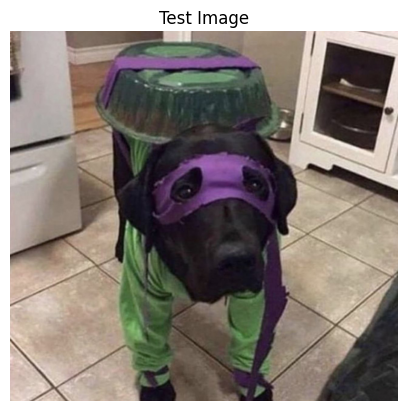

In [4]:
# NBVAL_IGNORE_OUTPUT
image_url = "https://github.com/zazamrykh/PicFinder/blob/main/images/doge.jpg?raw=true"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
plt.imshow(image)
plt.axis('off')
plt.title('Test Image')
plt.show()

## Multimodal Generation

TransformerBridge supports `pixel_values` directly in `generate()`. We use
`prepare_multimodal_inputs()` to process the image and text together,
then pass `pixel_values` to `generate()`.

The bridge's `generate()` method includes a KV cache (`use_past_kv_cache=True` by
default) that avoids recomputing previous tokens at each step — the same
approach as HuggingFace's native generation, but with full hook access for
interpretability.

In [5]:
# NBVAL_IGNORE_OUTPUT
question = "What do you see in this photo?"
prompt = f"USER: <image>\n{question} ASSISTANT:"

# Prepare multimodal inputs (handles image processing + tokenization)
inputs = model.prepare_multimodal_inputs(text=prompt, images=image)
input_ids = inputs['input_ids']
pixel_values = inputs['pixel_values']

# Pass any extra processor outputs (e.g. image_sizes for LlavaNext)
extra_kwargs = {k: v for k, v in inputs.items()
                if k not in ('input_ids', 'pixel_values', 'attention_mask')}

# Use generate() with KV cache for efficient autoregressive generation.
# use_past_kv_cache=True (the default) caches key/value projections so each
# step only runs the forward pass on the newest token.
generated_text = model.generate(
    input_ids,
    pixel_values=pixel_values,
    max_new_tokens=50,
    do_sample=False,
    use_past_kv_cache=True,
    return_type="str",
    **extra_kwargs,
)

print('Generated text:', generated_text)

Generated text: USER:  
What do you see in this photo? ASSISTANT: The image features a black dog wearing a green and purple costume, standing on a tiled floor. The dog appears to be a small breed, possibly a Chihuahua. The costume adds a playful and fun


Let's try with a different image to verify the model adapts its description:

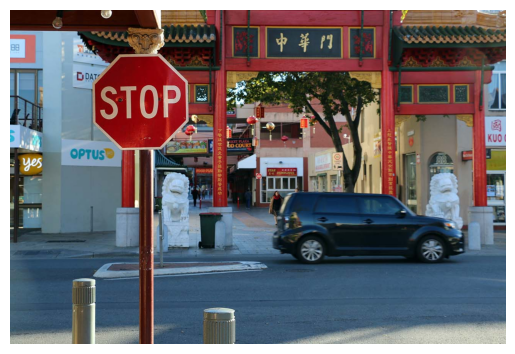

Generated text: USER:  
What do you see in this photo? ASSISTANT: The image is a collage of various scenes, including a street with cars and a tree. There are two cars in the scene, one on the left side and another on the right side. A truck can also be seen in the middle of


In [6]:
# NBVAL_IGNORE_OUTPUT
# Use a different image to verify the model adapts its description
image_url_2 = "https://www.ilankelman.org/stopsigns/australia.jpg"
response = requests.get(image_url_2)
image_2 = Image.open(BytesIO(response.content))
plt.imshow(image_2)
plt.axis('off')
plt.show()

inputs = model.prepare_multimodal_inputs(text=prompt, images=image_2)
input_ids = inputs['input_ids']
pixel_values = inputs['pixel_values']
extra_kwargs = {k: v for k, v in inputs.items()
                if k not in ('input_ids', 'pixel_values', 'attention_mask')}

generated_text = model.generate(
    input_ids,
    pixel_values=pixel_values,
    max_new_tokens=50,
    do_sample=False,
    use_past_kv_cache=True,
    return_type="str",
    **extra_kwargs,
)
print('Generated text:', generated_text)

## Attention Pattern Visualization

TransformerBridge provides `run_with_cache()` for capturing internal activations.
We can pass `pixel_values` to capture how the model attends to image tokens
during multimodal processing.

Since the model uses image tokens (represented as `<image>` placeholders that expand
into vision features), we can visualize how text tokens attend to image regions.

In [7]:
# NBVAL_IGNORE_OUTPUT
inputs = model.prepare_multimodal_inputs(text=prompt, images=image)

# Run with cache to capture all activations
with torch.no_grad():
    logits, cache = model.run_with_cache(
        inputs['input_ids'],
        pixel_values=inputs['pixel_values'],
    )

print(f'Logits shape: {logits.shape}')
print(f'Cache keys: {len(cache)} activations captured')
print(f'Sample keys: {list(cache.keys())[:5]}')

Logits shape: torch.Size([1, 596, 32064])
Cache keys: 1743 activations captured
Sample keys: ['embed.hook_in', 'embed.hook_out', 'hook_embed', 'vision_encoder.hook_in', 'vision_encoder.embeddings.hook_in']


In [8]:
# NBVAL_IGNORE_OUTPUT
if cv is not None:
    layer_to_visualize = 16
    tokens_to_show = 30

    # Find attention pattern in cache
    pattern_keys = [k for k in cache.keys() if f'blocks.{layer_to_visualize}' in k and 'pattern' in k]
    if pattern_keys:
        attention_pattern = cache[pattern_keys[0]]
        # Remove batch dim if present
        if attention_pattern.ndim == 4:
            attention_pattern = attention_pattern[0]

        # Get token labels from input_ids
        token_ids = inputs['input_ids'][0].cpu()
        str_tokens = model.tokenizer.convert_ids_to_tokens(token_ids)

        print(f'Layer {layer_to_visualize} Head Attention Patterns (last {tokens_to_show} tokens):')
        display(cv.attention.attention_patterns(
            tokens=str_tokens[-tokens_to_show:],
            attention=attention_pattern[:, -tokens_to_show:, -tokens_to_show:].float().cpu(),
        ))
    else:
        print(f'No attention pattern found for layer {layer_to_visualize}')
        print(f'Available attention-related keys: {[k for k in cache.keys() if "attn" in k][:10]}')
else:
    print('circuitsvis not available — skipping visualization')

Layer 16 Head Attention Patterns (last 30 tokens):


## Summary

TransformerBridge provides native multimodal support for LLaVA models:

- **`boot_transformers()`** loads the full vision+language pipeline
- **`prepare_multimodal_inputs()`** handles image processing and tokenization
- **`generate(pixel_values=...)`** runs multimodal generation with KV cache and hooks
- **`run_with_cache(pixel_values=...)`** captures activations including vision-language attention

The `generate()` method uses a KV cache by default (`use_past_kv_cache=True`),
so each generation step only computes the forward pass for the newest token while
retaining full hook access for interpretability.

Image tokens appear in the attention patterns, enabling analysis of how the model
integrates visual and textual information.